# Entropy Over Time (Scatter Plot)

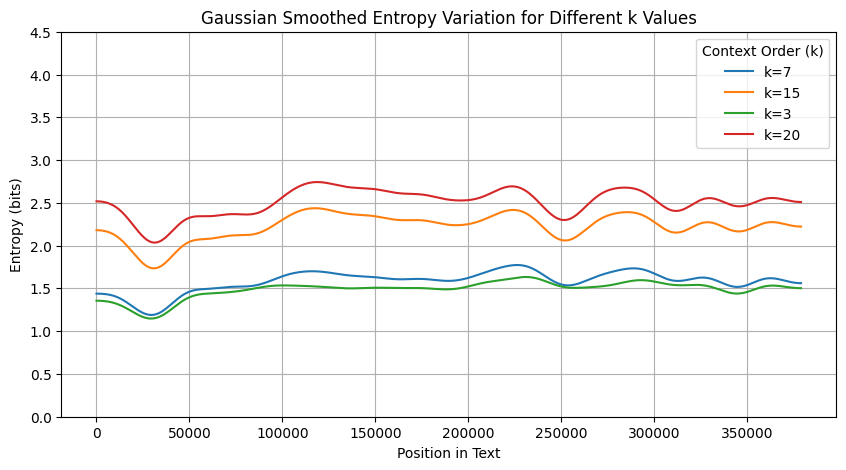

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import glob

# Define smoothing factor
sigma = 10000  

# Automatically find all entropy files matching the pattern "entropy_data_k*.csv"
files = glob.glob("entropy_data_k*.csv")

plt.figure(figsize=(10, 5))

# Loop through each file
for file in files:
    # Extract the value of k from the filename (assumes format "entropy_data_kX.csv")
    k_value = int(file.split("_k")[1].split(".csv")[0])  

    # Read entropy data
    data = pd.read_csv(file)

    # Apply Gaussian smoothing
    data["smoothed_entropy"] = gaussian_filter1d(data["entropy_value"], sigma=sigma)

    # Plot each k with a different color
    plt.plot(data["position"], data["smoothed_entropy"], label=f"k={k_value}")

# Plot settings
plt.xlabel("Position in Text")
plt.ylabel("Entropy (bits)")
plt.title("Gaussian Smoothed Entropy Variation for Different k Values")
plt.legend(title="Context Order (k)")
plt.grid(True)
plt.ylim(0, 4.5)

# Show plot
plt.show()


# K ValueS Used During the Text Generation

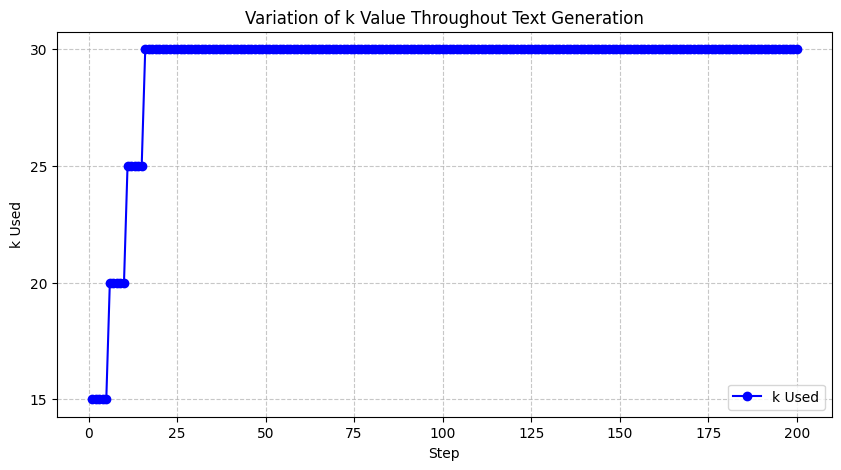

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the CSV file
df = pd.read_csv("k_values.csv")

# Plot the graph
plt.figure(figsize=(10, 5))
plt.plot(df["Step"], df["k_used"], marker='o', linestyle='-', color='b', label="k Used")

# Labels and title
plt.xlabel("Step")
plt.ylabel("k Used")
plt.title("Variation of k Value Throughout Text Generation")
plt.yticks(sorted(df["k_used"].unique()))
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

# Show the plot
plt.show()


# Relation Between Alpha and K

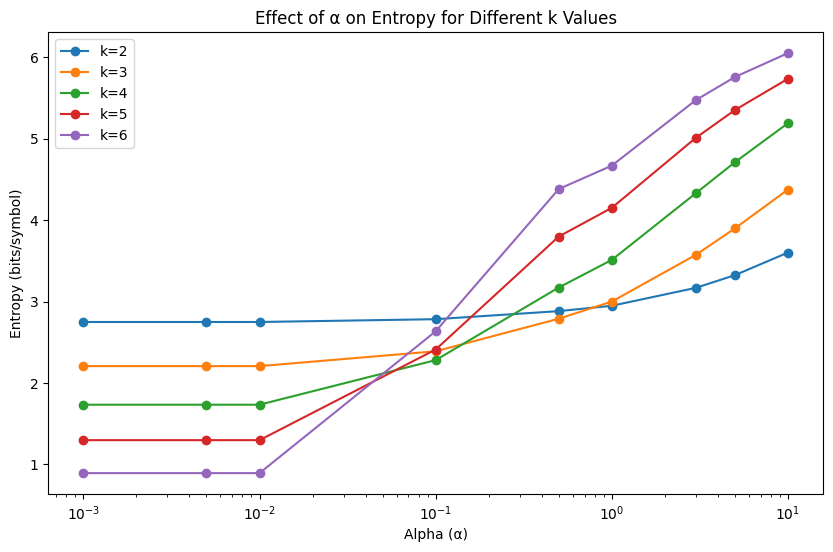

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("alpha_plot.csv")

# Extract entropy values (remove text)
df["entropy"] = df["entropy"].str.extract(r"([\d.]+)").astype(float)

# Plot
plt.figure(figsize=(10, 6))

for k in df["k"].unique():
    subset = df[df["k"] == k]
    plt.plot(subset["alpha"], subset["entropy"], marker="o", label=f"k={k}")

# Labels and legend
plt.xscale("log")  # Log scale for better visualization
plt.xlabel("Alpha (α)")
plt.ylabel("Entropy (bits/symbol)")
plt.title("Effect of α on Entropy for Different k Values")
plt.legend()
#plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()
